In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).csv
/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).xlsx


# 1. Preparation

## 1.1. Library

In [2]:
import re
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim

## 1.2. Data Acq. - Get data from dataset

In [3]:
df = pd.read_csv("/kaggle/input/datasets/zakiyff/crescent-moon-visibility-dataset-icop-derived/Crescent_Moon_Visibility_Dataset_(ICOP_Derived).csv")

In [4]:
df.head()

,date,country,visible,weather,observ,hijri_month,hijri_year,source
0,2013-03-12,Algeria,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
1,2013-03-12,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
2,2013-03-12,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
3,2013-03-12,Iran,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en
4,2013-03-12,Iran,1,clear,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en


In [5]:
# df = df[df["country"] == "Indonesia"]

## 1.3. Data Engineering - Extract city from `Observ` column

The `observ` column contains semi-structured text with a consistent pattern.
We can leverage this pattern using regular expressions to extract the city name from each observation.

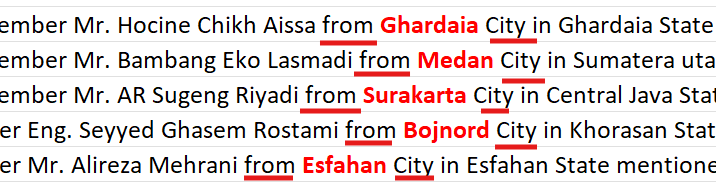


In [6]:
def extract_city(text):
    text = text.lower()
    
    match = re.search(r'from (.*?) city', text)
    if match:
        return match.group(1).strip().title()
    
    return None

In [7]:
df['city'] = df['observ'].apply(extract_city)

In [8]:
df.head()

,date,country,visible,weather,observ,hijri_month,hijri_year,source,city
0,2013-03-12,Algeria,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Ghardaia
1,2013-03-12,Indonesia,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Medan
2,2013-03-12,Indonesia,0,hazy,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Surakarta
3,2013-03-12,Iran,0,hazy,1 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Bojnord
4,2013-03-12,Iran,1,clear,2 . Time of observation: After ...,Jumadal Al-Aula,1434,https://astronomycenter.net/icop/jua34.html?l=en,Esfahan


city
Surakarta     251
Blacksburg    240
Shahreza      188
York          155
بنسليمان      131
Munich        116
ديربلوط       110
Cape Town      98
Dhaka          96
عيسى           88
Name: count, dtype: int64


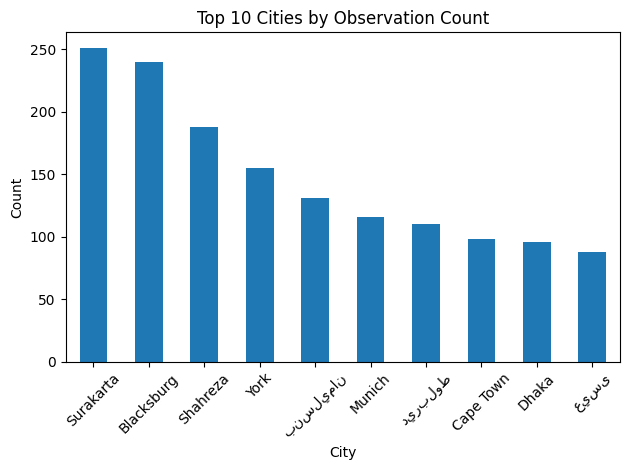

In [9]:
top_n = 10
top_cities = df['city'].value_counts().head(top_n)
print(top_cities)

# Visualize top city
top_cities.plot(kind='bar')

plt.title('Top 10 Cities by Observation Count')
plt.xlabel('City')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 1.4. Data Acq. - Get Lat & Long data based on `Country` & `City` column 

- so we're using ...
- and the result is
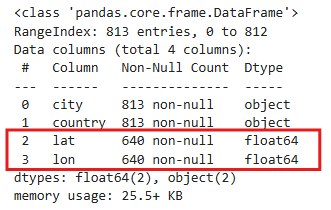

- we have problem that theres some location that didnt 

In [10]:
# # NB : This cell is only 1x use

# # Get unique city (with country)
# df_city = df[['city', 'country']].drop_duplicates().reset_index(drop=True)

# import pandas as pd
# from geopy.geocoders import Nominatim
# from geopy.extra.rate_limiter import RateLimiter

# geolocator = Nominatim(user_agent="hilal_project")
# geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# results = []

# for i, row in df_city.iterrows():
#     location = geocode(f"{row['city']}, {row['country']}")
    
#     if location:
#         lat, lon = location.latitude, location.longitude
#     else:
#         lat, lon = None, None
    
#     results.append((lat, lon))
    
#     # Log progress
#     if i % 20 == 0:
#         print(f"Processed {i}/{len(df_city)}")

# df_city[['lat', 'lon']] = results
# df_city.to_csv("city_lat_lon.csv", index=False)

In [11]:
# df_city = pd.read_csv("city_lat_lon.csv")

In [12]:
# df_city.head()

In [13]:
# df_city.info()

In [14]:
# df_priority = (
#     df[df['city'].isin(missing_cities)]
#     .groupby(['city', 'country'])
#     .size()
#     .reset_index(name='count')
#     .sort_values(by='count', ascending=False)
# )

In [15]:
# df_priority.head(20)

In [16]:
# df_priority.shape

In [17]:
# # long-lat checker
# import pandas as pd
# from geopy.geocoders import Nominatim
# from geopy.extra.rate_limiter import RateLimiter

# geolocator = Nominatim(user_agent="hilal_project")
# geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

# city = "Barka"
# country = "Oman"

# location = geocode(f"{city}, {country}")
# print(location.latitude, location.longitude)

In [18]:
# manual_mapping = {
#     'Jabal Khandamah': 'mecca',
#     'Tg. Bidara'     : 'tanjung bidara',
#     'Tg Bidara'      : 'tanjung bidara',
#     'Mcdonald Obs'   : 'texas',       # Observatorium McDonald adalah observatorium astronomi yang terletak di dekat komunitas tak berhubungan dari Fort Davis di Jeff Davis County, Texas, Amerika Serikat
#     'ديربلوط'           : 'palestine',
#     'Tanjung Bidara' : 'tanjung bidara',
#     'xxx'            : 'xxxxx',
#     'xxx'          : 'xxxxx',
#     'xxx'          : 'xxxxx',
#     'xxx'          : 'xxxxx',
#     'xxx'          : 'xxxxx',
#     'xxx'          : 'xxxxx',
#     'xxx'          : 'xxxxx',
# }